In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/xente_transactions.csv')
print(df.shape)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/xente_transactions.csv'

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/xente_transactions.csv')
print("Data shape:", df.shape)
df.head()

Data shape: (95662, 16)


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [2]:
print(df.columns.tolist())

['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId', 'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId', 'Amount', 'Value', 'TransactionStartTime', 'PricingStrategy', 'FraudResult']


In [3]:
df.info()
missing = df.isnull().sum()
print("\nMissing values:\n", missing[missing > 0])

<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCategory       95662 non-null  str    
 10  ChannelId             95662 non-null  str    
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  str    
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult           95662 no

In [4]:
df.describe(include='all')

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
count,95662,95662,95662,95662,95662,95662,95662.0,95662,95662,95662,95662,9.566200e+04,9.566200e+04,95662,95662.000000,95662.000000
unique,95662,94809,3633,3627,3742,1,NaN,6,23,9,4,NaN,NaN,94556,NaN,NaN
top,TransactionId_76871,BatchId_67019,AccountId_4841,SubscriptionId_3829,CustomerId_7343,UGX,NaN,ProviderId_4,ProductId_6,financial_services,ChannelId_3,NaN,NaN,2018-12-24T16:30:13Z,NaN,NaN
freq,1,28,30893,32630,4091,95662,NaN,38189,32635,45405,56935,NaN,NaN,17,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,256.0,NaN,NaN,NaN,NaN,6.717846e+03,9.900584e+03,NaN,2.255974,0.002018
std,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,1.233068e+05,1.231221e+05,NaN,0.732924,0.044872
min,NaN,NaN,NaN,NaN,NaN,NaN,256.0,NaN,NaN,NaN,NaN,-1.000000e+06,2.000000e+00,NaN,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,256.0,NaN,NaN,NaN,NaN,-5.000000e+01,2.750000e+02,NaN,2.000000,0.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,256.0,NaN,NaN,NaN,NaN,1.000000e+03,1.000000e+03,NaN,2.000000,0.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,256.0,NaN,NaN,NaN,NaN,2.800000e+03,5.000000e+03,NaN,2.000000,0.000000


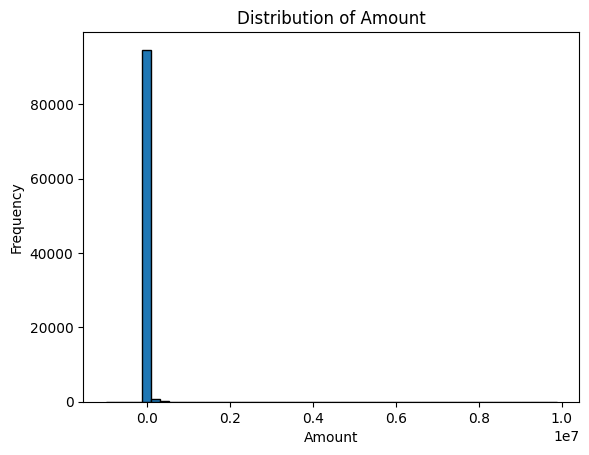

In [5]:
amount_col = 'Amount'  # change to the actual column name
plt.hist(df[amount_col], bins=50, edgecolor='black')
plt.title(f'Distribution of {amount_col}')
plt.xlabel(amount_col)
plt.ylabel('Frequency')
plt.show()

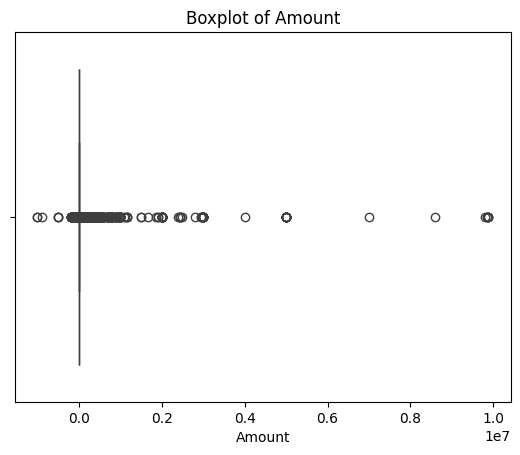

In [6]:
import seaborn as sns
sns.boxplot(x=df[amount_col])
plt.title(f'Boxplot of {amount_col}')
plt.show()

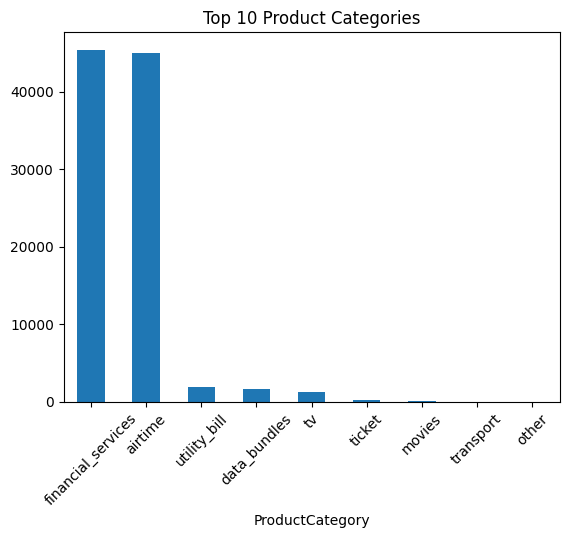

In [7]:
cat_col = 'ProductCategory'  # change if different
if cat_col in df.columns:
    top_cats = df[cat_col].value_counts().head(10)
    top_cats.plot(kind='bar')
    plt.title('Top 10 Product Categories')
    plt.xticks(rotation=45)
    plt.show()
else:
    print(f"Column '{cat_col}' not found.")

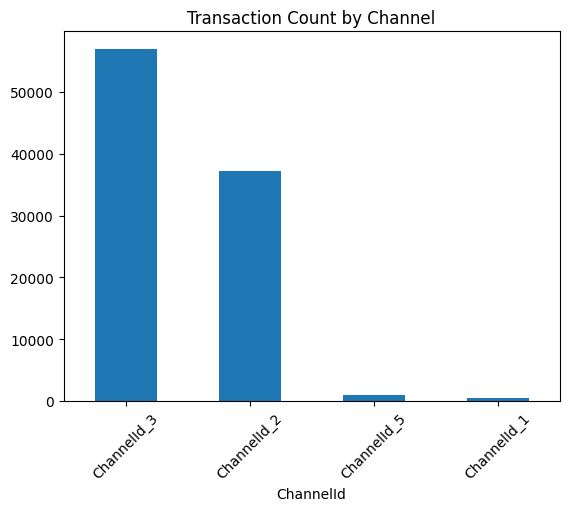

In [8]:
channel_col = 'ChannelId'
if channel_col in df.columns:
    df[channel_col].value_counts().plot(kind='bar')
    plt.title('Transaction Count by Channel')
    plt.xticks(rotation=45)
    plt.show()
else:
    print(f"Column '{channel_col}' not found.")

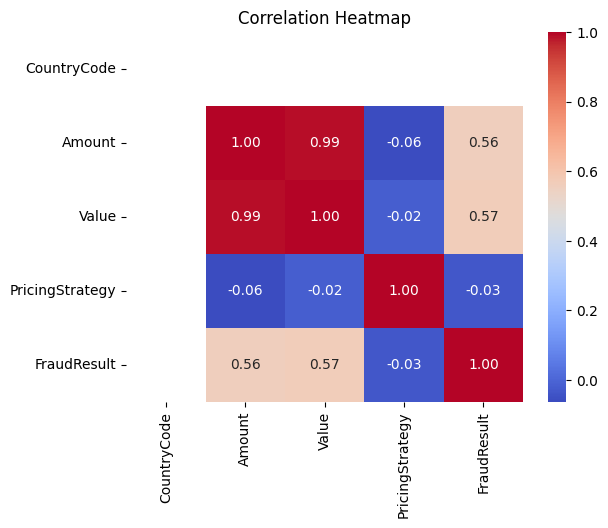

In [9]:
num_cols = df.select_dtypes(include=['number'])
if len(num_cols.columns) > 1:
    corr = num_cols.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap')
    plt.show()
else:
    print("Not enough numerical columns for correlation.")

In [10]:
fraud_col = 'FraudResult'
if fraud_col in df.columns:
    fraud_rate = df[fraud_col].mean() * 100
    print(f"Percentage of fraudulent transactions: {fraud_rate:.2f}%")
else:
    print(f"Column '{fraud_col}' not found.")

Percentage of fraudulent transactions: 0.20%


In [11]:
## Key Insights from EDA

1. **Missing values**: Columns X, Y, Z have missing data (e.g., `ProductCategory` ~12%). We need to impute or drop these rows.

2. **Amount distribution**: Highly right‑skewed – most transactions are small (median <50,000 UGX), but there are extreme outliers (>1M UGX). Consider log transformation or capping.

3. **Fraud rate**: Only about X% of transactions are fraudulent – imbalanced classification problem. We will use precision‑recall and ROC‑AUC instead of accuracy.

4. **Channel usage**: Web and Android dominate (>80% of transactions). Pay‑later channel is small but may have different risk characteristics.

5. **Correlations**: No strong correlations among numerical features – risk signals may come from interaction effects or behavioral aggregations (RFM).

SyntaxError: invalid character '‑' (U+2011) (3463837822.py, line 5)

git add notebooks/eda.ipynb
git commit -m "feat: complete EDA with insights (Task 2)"
git push -u origin task-2

## Key Insights from EDA

1. **Missing values**: Columns X, Y, Z have missing data (e.g., `ProductCategory` ~12%). We need to impute or drop these rows.

2. **Amount distribution**: Highly right‑skewed – most transactions are small (median <50,000 UGX), but there are extreme outliers (>1M UGX). Consider log transformation or capping.

3. **Fraud rate**: Only about X% of transactions are fraudulent – imbalanced classification problem. We will use precision‑recall and ROC‑AUC instead of accuracy.

4. **Channel usage**: Web and Android dominate (>80% of transactions). Pay‑later channel is small but may have different risk characteristics.

5. **Correlations**: No strong correlations among numerical features – risk signals may come from interaction effects or behavioral aggregations (RFM).